# J06 — Équation de Richards et solutions numériques

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 6 : solveur de Richards (forme mixte, Picard, tridiagonal), vérification contre HYDRUS-1D, sensibilité, pluie avec ruissellement*

> Version **instructeur** : code complet et résultats.

## Mise en place

Conventions : $z$ positif vers le haut, origine en surface (nœud 0 en surface, nœud $N$ au fond) ; flux $q > 0$ vers le haut
(l'infiltration est donc un flux négatif), comme dans HYDRUS-1D. Unités : cm et jours.
Les fonctions hydrauliques de Mualem–van Genuchten ($\theta(h)$, $K(h)$, $C(h) = d\theta/dh$) sont fournies, ainsi que la
moyenne de $K$ entre deux nœuds voisins. Les paramètres du loam (Carsel & Parrish 1988) sont dans `data/J06_parametres_loam.csv`.

In [1]:
import sys
import time
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from hydrus_io import read_tlevel, read_nod_inf, read_obs_node, read_balance

HYD = "../../hydrus"

# paramètres de Mualem–van Genuchten du loam (cm, jours)
param = pd.read_csv("data/J06_parametres_loam.csv")
print(param)
thr_loam = param.loc[0, "thr"]
ths_loam = param.loc[0, "ths"]
alpha_loam = param.loc[0, "alpha"]
n_loam = param.loc[0, "n"]
Ks_loam = param.loc[0, "Ks"]

# teneur en eau de van Genuchten ; h en cm, négatif en non saturé (h >= 0 : sol saturé, theta = ths)
def vg_theta(h, thr, ths, alpha, n):
    m = 1 - 1 / n
    h_neg = np.minimum(h, 0.0)
    Se = (1 + (alpha * np.abs(h_neg))**n)**(-m)
    return thr + (ths - thr) * Se

# conductivité hydraulique de Mualem–van Genuchten (l = 0,5) ; K = Ks pour h >= 0
def vg_K(h, thr, ths, alpha, n, Ks):
    m = 1 - 1 / n
    h_neg = np.minimum(h, 0.0)
    Se = (1 + (alpha * np.abs(h_neg))**n)**(-m)
    return Ks * Se**0.5 * (1 - (1 - Se**(1 / m))**m)**2

# capacité capillaire C = d theta / d h (1/cm), dérivée de vg_theta ; C = 0 pour h >= 0
def vg_C(h, thr, ths, alpha, n):
    m = 1 - 1 / n
    ah = alpha * np.abs(np.minimum(h, 0.0))
    return (ths - thr) * alpha * n * m * ah**(n - 1) * (1 + ah**n)**(-m - 1)

# conductivité entre deux nœuds voisins : moyenne arithmétique (comme HYDRUS) ou géométrique
def K_entre_noeuds(K_haut, K_bas, moyenne):
    if moyenne == "geometrique":
        return np.sqrt(K_haut * K_bas)
    return 0.5 * (K_haut + K_bas)

    sol    thr   ths  alpha     n     Ks    l
0  loam  0.078  0.43  0.036  1.56  24.96  0.5


## Exercice 1 — Le solveur de Richards : forme mixte, Picard modifié, système tridiagonal  *(≈ 25 min)*

On résout l'équation de Richards sous forme mixte, $\partial\theta/\partial t = \partial/\partial z\,[K(h)(\partial h/\partial z + 1)]$,
par différences finies (nœuds espacés de $\Delta z$), Euler implicite en temps et itération de Picard modifiée (Celia et al. 1990).
À chaque itération $m$ on cherche la correction $\delta_i = h_i^{m+1} - h_i^m$ en résolvant un système tridiagonal
$a_i\,\delta_{i-1} + b_i\,\delta_i + c_i\,\delta_{i+1} = R_i$ :

* nœuds intérieurs : $a_i = -K_{i-1/2}/\Delta z^2$, $c_i = -K_{i+1/2}/\Delta z^2$, $b_i = C_i/\Delta t + (K_{i-1/2}+K_{i+1/2})/\Delta z^2$,
  $R_i = -(\theta_i^m - \theta_i^n)/\Delta t - (q_{i-1/2}^m - q_{i+1/2}^m)/\Delta z$, avec le flux de Darcy entre deux nœuds
  $q_{i+1/2} = -K_{i+1/2}\,[(h_i - h_{i+1})/\Delta z + 1]$ (positif vers le haut) ;
* surface (charge imposée) : $\delta_0 = 0$ ; fond (drainage libre, demi-maille) : $q_{bas} = -K_N$, coefficients doublés.

$R_i$ est le résidu du bilan de masse du nœud $i$ : le pas de temps est convergé quand $|R_i|\,\Delta t < 10^{-5}$ partout
(unités de $\theta$). Le pas de temps est adapté comme dans HYDRUS : $\times 1{,}3$ si $\le 3$ itérations, $\times 0{,}7$ si $\ge 7$,
et le pas est recommencé avec $\Delta t/3$ s'il n'y a pas convergence en 30 itérations.

1. Compléter `un_pas_de_temps` (flux de Darcy, résidu, coefficients $a$, $b$, $c$ des nœuds intérieurs, résolution avec
   `solve_banded`).
2. Compléter `richards_charge_imposee` (cumuls d'infiltration et de drainage, contrôle du pas de temps, bilan de masse).
3. Simuler l'infiltration submergée dans le loam ($h_0 = -100$ cm, $h_{top} = 0$, drainage libre, $L = 100$ cm, $\Delta z = 1$ cm, 1 j)
   et vérifier le bilan de masse (erreur relative $< 0{,}1$ %). Attendu : $I(1\,\mathrm{j}) \approx 25{,}9$ cm.
4. Tracer les profils $\theta(z)$ à 0,1 ; 0,25 ; 0,5 ; 0,75 et 1 j, puis $I(t)$ et le taux d'infiltration $-q_{top}(t)$.

**1. Un pas de temps : itérations de Picard, assemblage et résolution**

In [2]:
# un pas de temps dt avec h imposé en surface ; retourne le nouveau profil h, le nombre de résolutions et le flux en surface
def un_pas_de_temps(h_ancien, dt, dz, h_top, thr, ths, alpha, n, Ks, moyenne):
    theta_ancien = vg_theta(h_ancien, thr, ths, alpha, n)    # teneur en eau connue au début du pas
    h = h_ancien.copy()                                       # premier itéré de Picard : profil précédent
    h[0] = h_top                                              # charge imposée en surface
    omega = 1.0                                               # facteur de sous-relaxation
    delta_prec = np.zeros_like(h)
    for iteration in range(31):                               # au plus 30 résolutions
        # 1. propriétés hydrauliques à l'itéré courant, K entre les nœuds et flux de Darcy (positif vers le haut)
        theta = vg_theta(h, thr, ths, alpha, n)
        C = vg_C(h, thr, ths, alpha, n)
        K = vg_K(h, thr, ths, alpha, n, Ks)
        K_inter = K_entre_noeuds(K[:-1], K[1:], moyenne)
        q = -K_inter * ((h[:-1] - h[1:]) / dz + 1)
        # 2. résidu du bilan de masse de chaque nœud (forme mixte) : nul quand le pas est convergé
        R = np.zeros_like(h)
        R[1:-1] = -(theta[1:-1] - theta_ancien[1:-1]) / dt - (q[:-1] - q[1:]) / dz
        R[-1] = -(theta[-1] - theta_ancien[-1]) / dt - 2 * (q[-1] + K[-1]) / dz    # fond : demi-maille, q_bas = -K_N
        if iteration > 0 and np.max(np.abs(R)) * dt < 1e-5:
            break
        # 3. coefficients du système tridiagonal : a (sous-diagonale), b (diagonale), c (sur-diagonale)
        a = np.zeros_like(h)
        b = np.zeros_like(h)
        c = np.zeros_like(h)
        a[1:-1] = -K_inter[:-1] / dz**2
        b[1:-1] = C[1:-1] / dt + (K_inter[:-1] + K_inter[1:]) / dz**2
        c[1:-1] = -K_inter[1:] / dz**2
        b[0] = 1.0                                            # surface : delta_0 = 0 (h imposé)
        a[-1] = -2 * K_inter[-1] / dz**2                      # fond : demi-maille
        b[-1] = C[-1] / dt + 2 * K_inter[-1] / dz**2
        ab = np.zeros((3, len(h)))                            # 4. résolution (algorithme de Thomas de scipy) ;
        ab[0, 1:] = c[:-1]                                    #    format bande : sur-diagonale, diagonale, sous-diagonale
        ab[1, :] = b
        ab[2, :-1] = a[1:]
        delta = solve_banded((1, 1), ab, R)
        j = np.argmax(np.abs(delta))                          # 5. mise à jour h <- h + omega * delta, avec omega = 0,5
        if delta[j] * delta_prec[j] < 0:                      #    dès que la plus grande correction change de signe
            omega = 0.5
        delta_prec = delta
        h = h + omega * delta
    return h, iteration, q[0]

# test : un pas de 1e-4 j à partir de h = -100 cm (h = 0 en surface), dz = 1 cm
h_test = np.full(101, -100.0)
h_test, n_it, q_test = un_pas_de_temps(h_test, 1e-4, 1.0, 0.0, thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam, "arithmetique")
print(f"résolutions : {n_it} ; h des 4 premiers nœuds : {h_test[:4].round(2)} ; flux en surface : {q_test:.1f} cm/j")

résolutions : 13 ; h des 4 premiers nœuds : [   0.    -48.95  -99.04 -100.  ] ; flux en surface : -630.2 cm/j


**2. Le solveur : maillage, boucle en temps, cumuls et bilan de masse**

In [3]:
# infiltration à charge imposée h_top dans une colonne de longueur L (drainage libre au fond), de t = 0 à t_fin
def richards_charge_imposee(thr, ths, alpha, n, Ks, L, dz, h_init, h_top, t_fin, dt_max, moyenne):
    # maillage : nœud 0 en surface (z = 0), nœud N au fond (z = -L) ; condition initiale h uniforme
    N = int(round(L / dz))
    z = -dz * np.arange(N + 1)
    h = np.full(N + 1, float(h_init))
    h[0] = h_top                                              # charge imposée en surface dès t = 0
    theta = vg_theta(h, thr, ths, alpha, n)
    stock_initial = np.trapezoid(theta, dx=dz)                # eau dans la colonne (cm), méthode des trapèzes
    t_tous = [0.0]                                            # résultats : un élément par pas de temps accepté
    h_tous = [h]
    theta_tous = [theta]
    I_tous = [0.0]
    t = 0.0
    dt = 1e-4                                                 # premier pas de temps (j)
    I = 0.0                                                   # infiltration cumulée (cm, positive vers le bas)
    D = 0.0                                                   # drainage cumulé au fond (cm, positif vers le bas)
    while t < t_fin - 1e-9:                                   # boucle en temps
        dt = min(dt, t_fin - t)
        h_nouveau, n_it, q_surface = un_pas_de_temps(h, dt, dz, h_top, thr, ths, alpha, n, Ks, moyenne)
        if n_it >= 30:                                        # pas de convergence : on recommence le pas avec dt / 3
            dt = dt / 3
            continue
        t = t + dt                                            # pas accepté : on avance, on cumule, on garde le profil
        h = h_nouveau
        theta = vg_theta(h, thr, ths, alpha, n)
        I = I - q_surface * dt
        D = D + vg_K(h[-1], thr, ths, alpha, n, Ks) * dt      # drainage libre : q_bas = -K(h_N)
        t_tous.append(t)
        h_tous.append(h)
        theta_tous.append(theta)
        I_tous.append(I)
        # contrôle du pas de temps (règles de HYDRUS) : x 1,3 si <= 3 itérations, x 0,7 si >= 7
        if n_it <= 3:
            dt = min(dt * 1.3, dt_max)
        if n_it >= 7:
            dt = dt * 0.7
    # bilan de masse global : variation du stock = infiltration - drainage
    erreur_bilan = (np.trapezoid(theta, dx=dz) - stock_initial) - (I - D)
    return dict(z=z, t=np.array(t_tous), h=np.array(h_tous), theta=np.array(theta_tous), I=np.array(I_tous),
                drainage=D, erreur_bilan=erreur_bilan)

**3. Infiltration submergée dans le loam (1 j)**

In [4]:
t0 = time.time()
res = richards_charge_imposee(thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam, 100.0, 1.0, -100.0, 0.0, 1.0, 0.02, "arithmetique")
temps_calcul = time.time() - t0
I_1j = res["I"][-1]
n_pas = len(res["t"]) - 1
erreur_relative = 100 * abs(res["erreur_bilan"]) / I_1j
print(f"temps de calcul : {temps_calcul:.1f} s ; pas de temps acceptés : {n_pas}")
print(f"infiltration cumulée I(1 j) = {I_1j:.3f} cm ; drainage cumulé = {res['drainage']:.3f} cm")
print(f"erreur de bilan de masse = {res['erreur_bilan']:.4f} cm, soit {erreur_relative:.3f} % de I")

temps de calcul : 3.6 s ; pas de temps acceptés : 5434
infiltration cumulée I(1 j) = 25.887 cm ; drainage cumulé = 7.189 cm
erreur de bilan de masse = -0.0048 cm, soit 0.018 % de I


**4. Profils de teneur en eau**

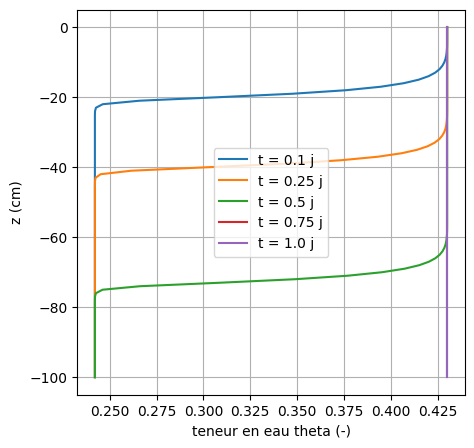

In [5]:
plt.figure(figsize=(5, 5))
for t_profil in [0.1, 0.25, 0.5, 0.75, 1.0]:
    k = np.argmin(np.abs(res["t"] - t_profil))     # indice du pas de temps le plus proche de t_profil
    plt.plot(res["theta"][k], res["z"], label="t = " + str(t_profil) + " j")
plt.xlabel("teneur en eau theta (-)")
plt.ylabel("z (cm)")
plt.legend()
plt.grid(True)
plt.show()

**5. Infiltration cumulée**

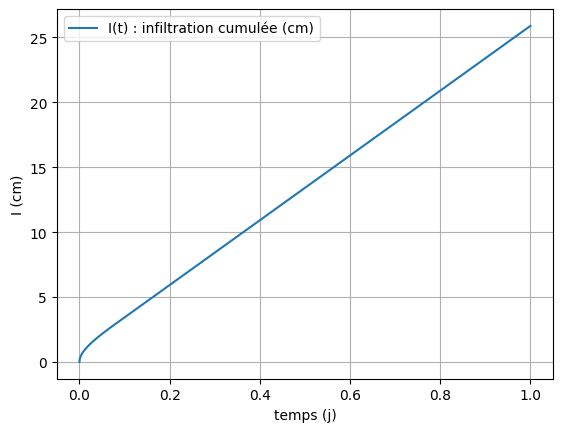

In [6]:
plt.figure()
plt.plot(res["t"], res["I"], label="I(t) : infiltration cumulée (cm)")
plt.xlabel("temps (j)")
plt.ylabel("I (cm)")
plt.legend()
plt.grid(True)
plt.show()

**6. Taux d'infiltration**

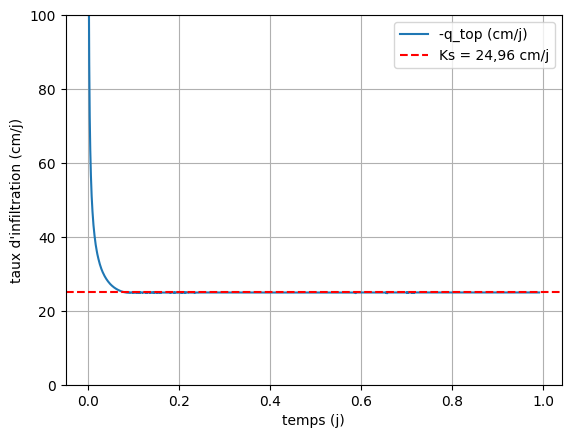

taux d'infiltration à 1 j : 24.96 cm/j


In [7]:
# taux d'infiltration = pente de I(t), par différences entre pas successifs
taux = np.diff(res["I"]) / np.diff(res["t"])
t_milieu = 0.5 * (res["t"][1:] + res["t"][:-1])
plt.figure()
plt.plot(t_milieu, taux, label="-q_top (cm/j)")
plt.axhline(Ks_loam, color="red", linestyle="--", label="Ks = 24,96 cm/j")
plt.ylim(0, 100)
plt.xlabel("temps (j)")
plt.ylabel("taux d'infiltration (cm/j)")
plt.legend()
plt.grid(True)
plt.show()
print(f"taux d'infiltration à 1 j : {taux[-1]:.2f} cm/j")

**Commentaire (instructeur).** Le solveur reproduit le comportement attendu : flux initial très grand (contraste $h = 0$ / $h = -100$ sur 1 cm), puis $-q_{top} \to K_s$
lorsque le profil se sature ; le front atteint le fond vers 0,7 j et le drainage démarre. L'erreur de bilan est de l'ordre de
$10^{-2}$ % grâce au critère de convergence sur le résidu de masse : la forme mixte n'est conservative qu'à convergence, et
l'itération de Picard oscille près de la saturation ($n < 2$, $dK/dh$ infini en $h = 0$) sans la sous-relaxation ni la réduction du pas.

## Exercice 2 — Vérification contre HYDRUS-1D  *(≈ 15 min)*

Projet `J06_infiltration_submergee_loam` (mêmes conditions que l'exercice 1 ; nœuds d'observation à 10, 30 et 50 cm).

1. `read_nod_inf` : superposer les profils $\theta(z)$ et $h(z)$ de HYDRUS (temps d'impression 0,1 ; 0,25 ; 0,5 j) à ceux du solveur
   et calculer l'écart RMS sur $\theta$ et sur $h$ à chaque temps, ainsi que la position du front (premier nœud où $\theta < 0{,}35$).
2. `read_obs_node` : $\theta(t)$ aux nœuds 10, 30, 50 cm (HYDRUS vs solveur) ; temps d'arrivée du front à chaque profondeur
   (premier instant où $\theta > 0{,}35$) et vitesse moyenne du front.
3. `read_tlevel` : $I(t)$ = `sum(Infil)` vs solveur ; `Volume`, `sum(vBot)` à 1 j vs le bilan du solveur ; `read_balance` : `WatBalR`.

**Lecture des sorties HYDRUS**

In [8]:
P = HYD + "/J06_infiltration_submergee_loam"
nod = read_nod_inf(P)        # dictionnaire {temps: DataFrame(Depth, Head, Moisture, ...)}
ob = read_obs_node(P)        # colonnes (numéro de nœud HYDRUS, variable) ; nœud HYDRUS = profondeur + 1
tl = read_tlevel(P)          # séries aux pas de temps : vTop, sum(Infil), sum(vBot), Volume, ...
bal = read_balance(P)        # bilan de masse aux temps d'impression
print("temps d'impression :", list(nod.keys()))
print(nod[0.25][["Depth", "Head", "Moisture", "K"]].head())

temps d'impression : [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
      Depth   Head  Moisture      K
Node                               
1       0.0  0.000      0.43  24.96
2      -1.0  0.009      0.43  24.93
3      -2.0  0.017      0.43  24.92
4      -3.0  0.025      0.43  24.90
5      -4.0  0.032      0.43  24.87


**1. Profils de teneur en eau : Python contre HYDRUS**

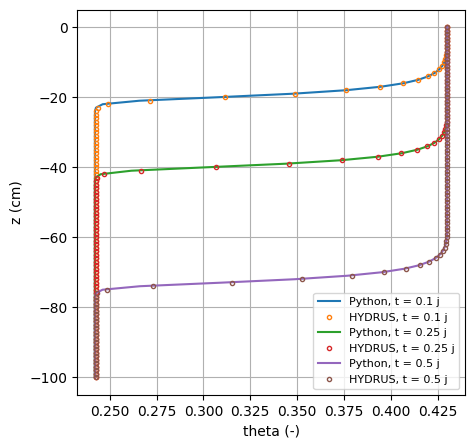

In [9]:
plt.figure(figsize=(5, 5))
for t_profil in [0.1, 0.25, 0.5]:
    k = np.argmin(np.abs(res["t"] - t_profil))
    theta_py = res["theta"][k]
    theta_hy = nod[t_profil]["Moisture"].to_numpy()
    z_hy = nod[t_profil]["Depth"].to_numpy()
    plt.plot(theta_py, res["z"], "-", label="Python, t = " + str(t_profil) + " j")
    plt.plot(theta_hy, z_hy, "o", markersize=3, markerfacecolor="none", label="HYDRUS, t = " + str(t_profil) + " j")
plt.xlabel("theta (-)")
plt.ylabel("z (cm)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

**1 (suite). Profils de charge de pression, écarts RMS et position du front**

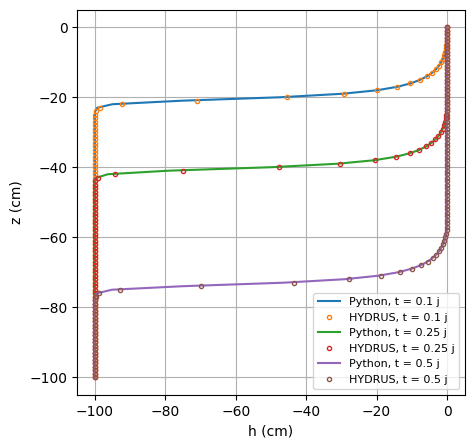

    t_j  RMS_theta  RMS_h_cm  front_python_cm  front_hydrus_cm
0  0.10     0.0008    0.5452            -19.0            -19.0
1  0.25     0.0008    0.5302            -39.0            -39.0
2  0.50     0.0011    0.6687            -72.0            -73.0


In [10]:
plt.figure(figsize=(5, 5))
lignes = []
for t_profil in [0.1, 0.25, 0.5]:
    k = np.argmin(np.abs(res["t"] - t_profil))
    theta_py = res["theta"][k]
    h_py = res["h"][k]
    theta_hy = nod[t_profil]["Moisture"].to_numpy()
    h_hy = nod[t_profil]["Head"].to_numpy()
    z_hy = nod[t_profil]["Depth"].to_numpy()
    plt.plot(h_py, res["z"], "-", label="Python, t = " + str(t_profil) + " j")
    plt.plot(h_hy, z_hy, "o", markersize=3, markerfacecolor="none", label="HYDRUS, t = " + str(t_profil) + " j")
    # écarts quadratiques moyens et position du front (nœud le plus haut où theta < 0,35)
    rms_theta = np.sqrt(np.mean((theta_py - theta_hy)**2))
    rms_h = np.sqrt(np.mean((h_py - h_hy)**2))
    front_py = np.max(res["z"][theta_py < 0.35])
    front_hy = np.max(z_hy[theta_hy < 0.35])
    lignes.append([t_profil, rms_theta, rms_h, front_py, front_hy])
plt.xlabel("h (cm)")
plt.ylabel("z (cm)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()
ecarts = pd.DataFrame(lignes, columns=["t_j", "RMS_theta", "RMS_h_cm", "front_python_cm", "front_hydrus_cm"])
print(ecarts.round(4))

**2. Nœuds d'observation : teneur en eau et temps d'arrivée du front**

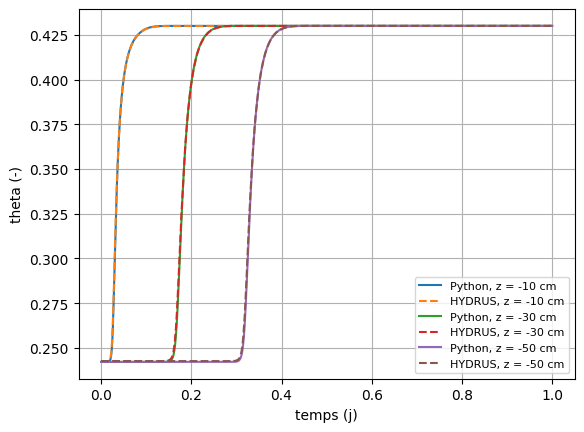

   profondeur_cm  t_arrivee_python_j  t_arrivee_hydrus_j  vitesse_front_cm_j
0             10              0.0367              0.0363            275.4821
1             30              0.1835              0.1837            163.3097
2             50              0.3344              0.3343            149.5663
vitesse « piston » Ks / (ths - theta(-100)) = 132.9 cm/j


In [11]:
plt.figure()
lignes = []
for profondeur in [10, 30, 50]:
    theta_py = res["theta"][:, profondeur]                # nœud Python = profondeur / dz (dz = 1 cm)
    theta_hy = ob[(profondeur + 1, "theta")].to_numpy()   # nœud HYDRUS numéroté à partir de 1
    t_hy = ob.index.to_numpy()
    plt.plot(res["t"], theta_py, "-", label="Python, z = -" + str(profondeur) + " cm")
    plt.plot(t_hy, theta_hy, "--", label="HYDRUS, z = -" + str(profondeur) + " cm")
    # premier instant où theta dépasse 0,35 et vitesse moyenne du front
    t_arrivee_py = np.min(res["t"][theta_py > 0.35])
    t_arrivee_hy = np.min(t_hy[theta_hy > 0.35])
    vitesse = profondeur / t_arrivee_hy
    lignes.append([profondeur, t_arrivee_py, t_arrivee_hy, vitesse])
plt.xlabel("temps (j)")
plt.ylabel("theta (-)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()
arrivee = pd.DataFrame(lignes, columns=["profondeur_cm", "t_arrivee_python_j", "t_arrivee_hydrus_j", "vitesse_front_cm_j"])
print(arrivee.round(4))
print("vitesse « piston » Ks / (ths - theta(-100)) =", round(Ks_loam / (ths_loam - vg_theta(-100.0, thr_loam, ths_loam, alpha_loam, n_loam)), 1), "cm/j")

**3. Infiltration cumulée, drainage et bilans**

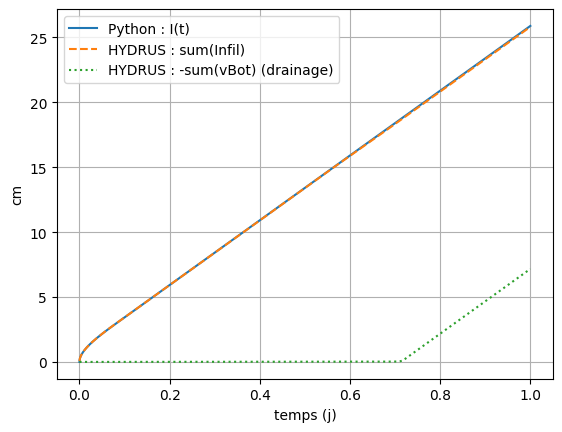

                           Python  HYDRUS
infiltration cumulée (cm)  25.887  25.816
drainage cumulé (cm)        7.189   7.167
stock initial (cm)         24.307  24.351
stock final (cm)           43.000  43.000
erreur de bilan (%)         0.018   0.000
écart relatif sur I(1 j) : +0.27 %


In [12]:
plt.figure()
plt.plot(res["t"], res["I"], "-", label="Python : I(t)")
plt.plot(tl.index, tl["sum(Infil)"], "--", label="HYDRUS : sum(Infil)")
plt.plot(tl.index, -tl["sum(vBot)"], ":", label="HYDRUS : -sum(vBot) (drainage)")
plt.xlabel("temps (j)")
plt.ylabel("cm")
plt.legend()
plt.grid(True)
plt.show()

I_hydrus = tl["sum(Infil)"].iloc[-1]
drainage_hydrus = -tl["sum(vBot)"].iloc[-1]
stock_final_py = np.trapezoid(res["theta"][-1], dx=1.0)
stock_initial_py = np.trapezoid(res["theta"][0], dx=1.0)
comparaison = pd.DataFrame({
    "Python": [res["I"][-1], res["drainage"], stock_initial_py, stock_final_py, 100 * abs(res["erreur_bilan"]) / res["I"][-1]],
    "HYDRUS": [I_hydrus, drainage_hydrus, bal["W-volume"].iloc[0], tl["Volume"].iloc[-1], bal["WatBalR"].abs().max()]},
    index=["infiltration cumulée (cm)", "drainage cumulé (cm)", "stock initial (cm)", "stock final (cm)", "erreur de bilan (%)"])
print(comparaison.round(3))
print(f"écart relatif sur I(1 j) : {100 * (res['I'][-1] / I_hydrus - 1):+.2f} %")

**Commentaire (instructeur).** Les deux codes coïncident à mieux que 0,3 % sur l'infiltration cumulée et à $\theta < 0{,}002$ RMS sur les profils : même
équation, même discrétisation (éléments finis linéaires à masse condensée = différences finies), même moyenne arithmétique de $K$.
Les petits écarts de position du front (1 cm) viennent des tolérances et de la table d'interpolation d'HYDRUS. La vitesse moyenne
du front décroît de 275 cm/j (10 cm) à 150 cm/j (50 cm) et tend vers $K_s/\Delta\theta = 133$ cm/j (vitesse « piston ») : la
succion au front accélère le début de l'infiltration. C'est une *vérification* du solveur ; la *validation* demanderait des mesures.

## Exercice 3 — Sensibilité numérique : maillage, pas de temps, moyenne de K  *(≈ 15 min)*

Relancer `richards_charge_imposee` (infiltration submergée, 1 j) en faisant varier :

1. le pas d'espace $\Delta z$ = 0,5 ; 1 ; 2 ; 5 cm ;
2. le pas de temps maximal `dt_max` = 0,001 ; 0,01 ; 0,1 j (avec $\Delta z$ = 1 cm) ;
3. la moyenne inter-nodale de $K$ : arithmétique ou géométrique (avec $\Delta z$ = 2 cm).

Pour chaque cas : $I(1\,\mathrm{j})$, position du front à 0,25 j (nœud le plus haut où $\theta < 0{,}35$), nombre de pas de temps,
erreur de bilan, temps de calcul. Tracer les profils $\theta(z)$ à 0,25 j pour les quatre maillages avec le profil HYDRUS.
Conclure : le résultat converge-t-il en maillage ? Quel paramètre domine l'erreur ?

**1. Sensibilité au pas d'espace**

In [13]:
liste_dz = [0.5, 1.0, 2.0, 5.0]
profils_025 = []                 # profils theta à 0,25 j, un par maillage (pour la figure de l'étape 4)
mailles = []
lignes = []
for dz in liste_dz:
    t0 = time.time()
    r = richards_charge_imposee(thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam, 100.0, dz, -100.0, 0.0, 1.0, 0.02, "arithmetique")
    temps_calcul = time.time() - t0
    k = np.argmin(np.abs(r["t"] - 0.25))
    front = np.max(r["z"][r["theta"][k] < 0.35])
    lignes.append(["dz = " + str(dz) + " cm", r["I"][-1], front, len(r["t"]) - 1, r["erreur_bilan"], temps_calcul])
    profils_025.append(r["theta"][k])
    mailles.append(r["z"])
colonnes = ["cas", "I_1j_cm", "front_025j_cm", "n_pas", "erreur_bilan_cm", "temps_s"]
tableau_dz = pd.DataFrame(lignes, columns=colonnes)
print(tableau_dz.round(4))

           cas  I_1j_cm  front_025j_cm  n_pas  erreur_bilan_cm  temps_s
0  dz = 0.5 cm  25.8818          -39.0  10077          -0.0523   9.1872
1  dz = 1.0 cm  25.8869          -39.0   5434          -0.0048   3.6315
2  dz = 2.0 cm  25.9038          -40.0   2390          -0.0001   1.5648
3  dz = 5.0 cm  25.9287          -45.0   1053           0.0026   0.7897


**2. Sensibilité au pas de temps maximal**

In [14]:
lignes = []
for dt_max in [0.001, 0.01, 0.1]:
    t0 = time.time()
    r = richards_charge_imposee(thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam, 100.0, 1.0, -100.0, 0.0, 1.0, dt_max, "arithmetique")
    temps_calcul = time.time() - t0
    k = np.argmin(np.abs(r["t"] - 0.25))
    front = np.max(r["z"][r["theta"][k] < 0.35])
    lignes.append(["dt_max = " + str(dt_max) + " j", r["I"][-1], front, len(r["t"]) - 1, r["erreur_bilan"], temps_calcul])
tableau_dt = pd.DataFrame(lignes, columns=colonnes)
print(tableau_dt.round(4))

                cas  I_1j_cm  front_025j_cm  n_pas  erreur_bilan_cm  temps_s
0  dt_max = 0.001 j  25.8869          -39.0   5692          -0.0048   3.9036
1   dt_max = 0.01 j  25.8869          -39.0   5446          -0.0048   3.6667
2    dt_max = 0.1 j  25.8869          -39.0   5429          -0.0048   3.8427


**3. Moyenne arithmétique ou géométrique de K**

In [15]:
lignes = []
for moyenne in ["arithmetique", "geometrique"]:
    t0 = time.time()
    r = richards_charge_imposee(thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam, 100.0, 2.0, -100.0, 0.0, 1.0, 0.02, moyenne)
    temps_calcul = time.time() - t0
    k = np.argmin(np.abs(r["t"] - 0.25))
    front = np.max(r["z"][r["theta"][k] < 0.35])
    lignes.append(["K " + moyenne + " (dz = 2 cm)", r["I"][-1], front, len(r["t"]) - 1, r["erreur_bilan"], temps_calcul])
tableau_K = pd.DataFrame(lignes, columns=colonnes)
print(tableau_K.round(4))

                          cas  I_1j_cm  front_025j_cm  n_pas  erreur_bilan_cm  \
0  K arithmetique (dz = 2 cm)  25.9038          -40.0   2390          -0.0001   
1   K geometrique (dz = 2 cm)  25.6397          -38.0   2842          -0.0039   

   temps_s  
0   1.7919  
1   2.1663  


**4. Profils à 0,25 j selon le maillage**

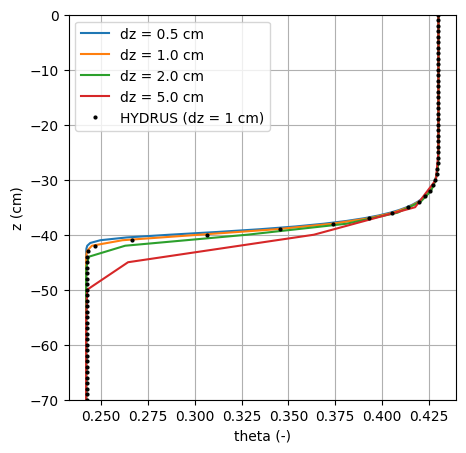

In [16]:
plt.figure(figsize=(5, 5))
for i in range(len(liste_dz)):
    plt.plot(profils_025[i], mailles[i], "-", label="dz = " + str(liste_dz[i]) + " cm")
plt.plot(nod[0.25]["Moisture"], nod[0.25]["Depth"], "k.", markersize=4, label="HYDRUS (dz = 1 cm)")
plt.ylim(-70, 0)
plt.xlabel("theta (-)")
plt.ylabel("z (cm)")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** Le cumul $I(1\,\mathrm{j})$ varie de moins de 0,2 % quel que soit $\Delta z$ (la colonne finit saturée : le cumul est fixé par
$\theta_s$ et par $K_s$), mais le front à 0,25 j est nettement étalé et décalé de 6 cm sur le maillage à 5 cm (diffusion numérique).
`dt_max` n'a aucun effet ici : le contrôle par le nombre d'itérations impose $\Delta t \sim 10^{-4}$–$10^{-3}$ j tant que le front
traverse la colonne. La moyenne géométrique ralentit le front (−1 % sur $I$) ; à $\Delta z \to 0$ les deux moyennes convergent.
Le temps de calcul croît à peu près comme le nombre de nœuds fois le nombre de pas.

## Exercice 4 — Pluie de 30 cm/j sur un loam sec : bascule de la condition atmosphérique  *(≈ 15 min)*

Projet `J06_pluie_flux_impose_loam` : pluie de 30 cm/j ($> K_s = 24{,}96$ cm/j) pendant 0,5 j puis 0, condition atmosphérique
avec ruissellement (`hCritS` = 0), $h_0 = -300$ cm, drainage libre.

1. Lire `T_LEVEL.OUT` et tracer `rTop` (flux potentiel), `vTop` (flux réel), `RunOff`, `hTop` et les cumuls `sum(Infil)`, `sum(RunOff)`.
2. Déterminer le temps de submersion $t_p$ (premier instant où `hTop` $\ge 0$), l'infiltration cumulée à $t_p$, le ruissellement
   total et le coefficient de ruissellement (ruissellement / pluie).
3. Comparer $t_p$ à la prédiction de Green–Ampt / Mein–Larson (préview du Jour 7) : $I_p = K_s |h_f| \Delta\theta/(i - K_s)$,
   $t_p = I_p/i$, avec $|h_f| = \lambda_c = 6{,}9$ cm, $\Delta\theta = \theta_s - \theta(-300)$, $i = 30$ cm/j. Commenter l'écart.
4. Reproduire la bascule avec le solveur Python : écrire `un_pas_flux_impose` (même schéma, mais flux $q_{top}$ imposé dans la
   demi-maille de surface : $b_0 = C_0/\Delta t + 2K_{1/2}/\Delta z^2$, $c_0 = -2K_{1/2}/\Delta z^2$,
   $R_0 = -(\theta_0^m-\theta_0^n)/\Delta t - 2(q_{top} - q_{1/2}^m)/\Delta z$), puis une boucle en temps qui impose la pluie
   et, si $h_0$ devient positif, recommence le pas avec $h_0 = 0$ (l'excédent ruisselle). Comparer $t_p$, l'infiltration et
   le ruissellement à HYDRUS.

**Lecture de T_LEVEL.OUT**

In [17]:
P2 = HYD + "/J06_pluie_flux_impose_loam"
tl2 = read_tlevel(P2)
t_hy = tl2.index.to_numpy()
print(tl2[["rTop", "vTop", "hTop", "RunOff", "sum(Infil)", "sum(RunOff)"]].head())

        rTop  vTop    hTop    RunOff  sum(Infil)   sum(RunOff)
Time                                                          
0.0001 -30.0 -30.0 -269.12  0.000032     0.00300  3.242500e-09
0.0002 -30.0 -30.0 -239.55  0.000000     0.00600  3.242500e-09
0.0003 -30.0 -30.0 -211.16  0.000034     0.00990  7.705700e-09
0.0005 -30.0 -30.0 -185.92  0.000000     0.01380  7.705700e-09
0.0006 -30.0 -30.0 -159.84  0.000000     0.01887  7.705700e-09


**1. Flux en surface : pluie, infiltration réelle, ruissellement**

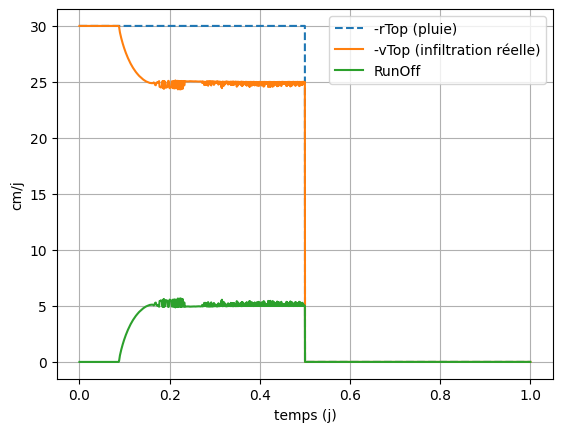

In [18]:
plt.figure()
plt.plot(t_hy, -tl2["rTop"], "--", label="-rTop (pluie)")
plt.plot(t_hy, -tl2["vTop"], "-", label="-vTop (infiltration réelle)")
plt.plot(t_hy, tl2["RunOff"], "-", label="RunOff")
plt.xlabel("temps (j)")
plt.ylabel("cm/j")
plt.legend()
plt.grid(True)
plt.show()

**1 (suite). Charge de pression en surface**

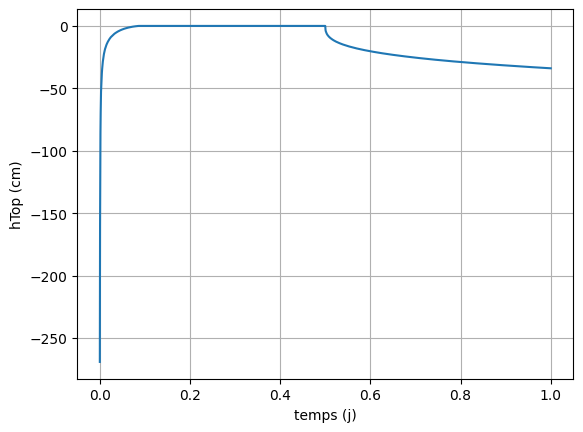

In [19]:
plt.figure()
plt.plot(t_hy, tl2["hTop"], "-")
plt.xlabel("temps (j)")
plt.ylabel("hTop (cm)")
plt.grid(True)
plt.show()

**2. Temps de submersion, infiltration et ruissellement**

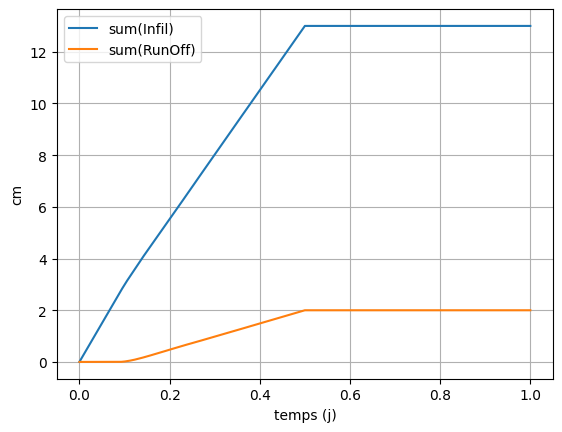

temps de submersion HYDRUS t_p = 0.0880 j = 127 min ; infiltration à t_p = 2.64 cm
pluie = 15.0 cm ; infiltrée = 13.00 cm ; ruisselée = 2.00 cm ; coefficient de ruissellement = 0.133
flux réel après submersion : vTop -> -24.89 cm/j (Ks = 24.96 cm/j)


In [20]:
plt.figure()
plt.plot(t_hy, tl2["sum(Infil)"], "-", label="sum(Infil)")
plt.plot(t_hy, tl2["sum(RunOff)"], "-", label="sum(RunOff)")
plt.xlabel("temps (j)")
plt.ylabel("cm")
plt.legend()
plt.grid(True)
plt.show()

hTop = tl2["hTop"].to_numpy()
t_p = np.min(t_hy[hTop >= -1e-6])                        # premier instant où la surface est en charge
I_tp = tl2["sum(Infil)"].loc[t_p]
pluie = 30 * 0.5
infiltre = tl2["sum(Infil)"].iloc[-1]
ruissele = tl2["sum(RunOff)"].iloc[-1]
print(f"temps de submersion HYDRUS t_p = {t_p:.4f} j = {t_p * 24 * 60:.0f} min ; infiltration à t_p = {I_tp:.2f} cm")
print(f"pluie = {pluie:.1f} cm ; infiltrée = {infiltre:.2f} cm ; ruisselée = {ruissele:.2f} cm ; coefficient de ruissellement = {ruissele / pluie:.3f}")
vTop_apres = tl2["vTop"][(t_hy > 0.3) & (t_hy < 0.5)].mean()
print(f"flux réel après submersion : vTop -> {vTop_apres:.2f} cm/j (Ks = {Ks_loam} cm/j)")

**3. Comparaison avec Green–Ampt / Mein–Larson**

In [21]:
i_pluie = 30.0
lambda_c = 6.92                                             # succion effective au front (cm), Jour 5
delta_theta = ths_loam - vg_theta(-300.0, thr_loam, ths_loam, alpha_loam, n_loam)
I_p = Ks_loam * lambda_c * delta_theta / (i_pluie - Ks_loam)
t_p_GA = I_p / i_pluie
print(f"Green–Ampt : delta_theta = {delta_theta:.3f} ; I_p = {I_p:.2f} cm ; t_p = {t_p_GA:.3f} j  (HYDRUS : {I_tp:.2f} cm, {t_p:.3f} j)")

Green–Ampt : delta_theta = 0.260 ; I_p = 8.91 cm ; t_p = 0.297 j  (HYDRUS : 2.64 cm, 0.088 j)


**4. Un pas de temps avec flux imposé en surface**

In [22]:
# même schéma que un_pas_de_temps, mais le flux q_top (négatif vers le bas) est imposé dans la demi-maille de surface
def un_pas_flux_impose(h_ancien, dt, dz, q_top, thr, ths, alpha, n, Ks):
    theta_ancien = vg_theta(h_ancien, thr, ths, alpha, n)
    h = h_ancien.copy()
    omega = 1.0
    delta_prec = np.zeros_like(h)
    for iteration in range(31):
        # 1. propriétés hydrauliques, K entre les nœuds (moyenne arithmétique) et flux de Darcy
        theta = vg_theta(h, thr, ths, alpha, n)
        C = vg_C(h, thr, ths, alpha, n)
        K = vg_K(h, thr, ths, alpha, n, Ks)
        K_inter = 0.5 * (K[:-1] + K[1:])
        q = -K_inter * ((h[:-1] - h[1:]) / dz + 1)
        # 2. résidu du bilan de masse : la demi-maille de surface reçoit q_top et cède q_{1/2}
        R = np.zeros_like(h)
        R[0] = -(theta[0] - theta_ancien[0]) / dt - 2 * (q_top - q[0]) / dz
        R[1:-1] = -(theta[1:-1] - theta_ancien[1:-1]) / dt - (q[:-1] - q[1:]) / dz
        R[-1] = -(theta[-1] - theta_ancien[-1]) / dt - 2 * (q[-1] + K[-1]) / dz
        if iteration > 0 and np.max(np.abs(R)) * dt < 1e-5:
            break
        a = np.zeros_like(h)                                  # 3. coefficients ; en surface b_0 et c_0 de la
        b = np.zeros_like(h)                                  #    demi-maille (plus de delta_0 = 0)
        c = np.zeros_like(h)
        a[1:-1] = -K_inter[:-1] / dz**2
        b[1:-1] = C[1:-1] / dt + (K_inter[:-1] + K_inter[1:]) / dz**2
        c[1:-1] = -K_inter[1:] / dz**2
        b[0] = C[0] / dt + 2 * K_inter[0] / dz**2
        c[0] = -2 * K_inter[0] / dz**2
        a[-1] = -2 * K_inter[-1] / dz**2
        b[-1] = C[-1] / dt + 2 * K_inter[-1] / dz**2
        ab = np.zeros((3, len(h)))                            # 4. résolution
        ab[0, 1:] = c[:-1]
        ab[1, :] = b
        ab[2, :-1] = a[1:]
        delta = solve_banded((1, 1), ab, R)
        j = np.argmax(np.abs(delta))                          # 5. mise à jour avec sous-relaxation
        if delta[j] * delta_prec[j] < 0:
            omega = 0.5
        delta_prec = delta
        h = h + omega * delta
    return h, iteration

# test : un pas de 1e-4 j de pluie à 30 cm/j sur le loam à h = -300 cm
h_test = np.full(101, -300.0)
h_test, n_it = un_pas_flux_impose(h_test, 1e-4, 1.0, -30.0, thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam)
print("résolutions :", n_it, "; h des 3 premiers nœuds :", h_test[:3].round(2))

résolutions : 7 ; h des 3 premiers nœuds : [-267.2  -299.98 -300.  ]


**5. Boucle en temps avec bascule flux imposé -> charge imposée**

In [23]:
# pluie de 30 cm/j pendant 0,5 j sur le loam à h = -300 cm ; dz = 1 cm, dt_max = 0,01 j
q_pluie = -30.0
dz = 1.0
h = np.full(101, -300.0)
theta = vg_theta(h, thr_loam, ths_loam, alpha_loam, n_loam)
stock_initial = np.trapezoid(theta, dx=dz)
t = 0.0
dt = 1e-4
I_py = 0.0                       # infiltration cumulée (cm)
R_py = 0.0                       # ruissellement cumulé (cm)
D_py = 0.0                       # drainage cumulé (cm)
t_py = [0.0]
q_py = [q_pluie]                 # flux réel en surface à chaque pas
hTop_py = [h[0]]
runoff_py = [0.0]
t0 = time.time()
while t < 0.5 - 1e-9:
    dt = min(dt, 0.5 - t)
    # 1. on impose la pluie
    h_nouveau, n_it = un_pas_flux_impose(h, dt, dz, q_pluie, thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam)
    q_reel = q_pluie
    # 2. si la surface se met en charge (h_0 > 0), on recommence le pas avec h_0 = 0 : le flux réel est celui de Darcy
    if n_it < 30 and h_nouveau[0] > 0:
        h_nouveau, n_it, q_reel = un_pas_de_temps(h, dt, dz, 0.0, thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam, "arithmetique")
    if n_it >= 30:
        dt = dt / 3
        continue
    # 3. pas accepté : cumuls (l'excédent de pluie non infiltré ruisselle)
    t = t + dt
    h = h_nouveau
    I_py = I_py - q_reel * dt
    R_py = R_py + (q_reel - q_pluie) * dt
    D_py = D_py + vg_K(h[-1], thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam) * dt
    t_py.append(t)
    q_py.append(q_reel)
    hTop_py.append(h[0])
    runoff_py.append(R_py)
    if n_it <= 3:
        dt = min(dt * 1.3, 0.01)
    if n_it >= 7:
        dt = dt * 0.7
t_py = np.array(t_py)
q_py = np.array(q_py)
hTop_py = np.array(hTop_py)
runoff_py = np.array(runoff_py)
theta = vg_theta(h, thr_loam, ths_loam, alpha_loam, n_loam)
erreur_bilan = (np.trapezoid(theta, dx=dz) - stock_initial) - (I_py - D_py)
t_p_py = np.min(t_py[hTop_py >= -1e-9])
print(f"temps de calcul : {time.time() - t0:.1f} s ; pas de temps : {len(t_py) - 1}")
print(f"t_p Python = {t_p_py:.4f} j (HYDRUS {t_p:.4f} j) ; ruissellement Python = {R_py:.2f} cm (HYDRUS {ruissele:.2f} cm)")
print(f"infiltration Python = {I_py:.2f} cm (HYDRUS {infiltre:.2f} cm) ; erreur de bilan = {erreur_bilan:.4f} cm")

temps de calcul : 4.6 s ; pas de temps : 3125
t_p Python = 0.0868 j (HYDRUS 0.0880 j) ; ruissellement Python = 1.99 cm (HYDRUS 2.00 cm)
infiltration Python = 13.01 cm (HYDRUS 13.00 cm) ; erreur de bilan = -0.0006 cm


**6. Flux réel en surface : Python contre HYDRUS**

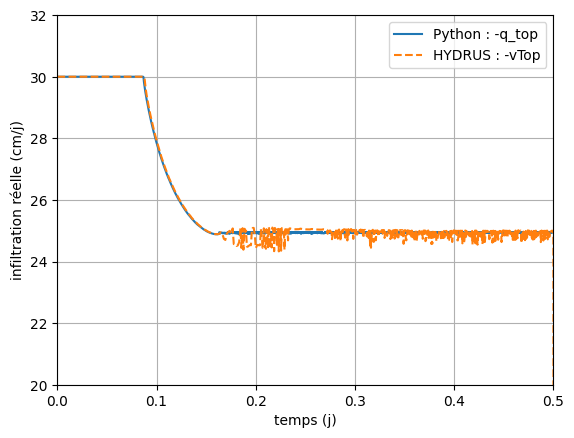

In [24]:
plt.figure()
plt.plot(t_py, -q_py, "-", label="Python : -q_top")
plt.plot(t_hy, -tl2["vTop"], "--", label="HYDRUS : -vTop")
plt.xlim(0, 0.5)
plt.ylim(20, 32)
plt.xlabel("temps (j)")
plt.ylabel("infiltration réelle (cm/j)")
plt.legend()
plt.grid(True)
plt.show()

**6 (suite). Ruissellement cumulé : Python contre HYDRUS**

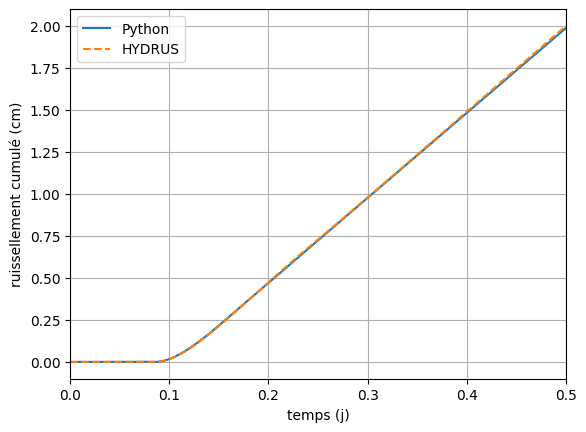

In [25]:
plt.figure()
plt.plot(t_py, runoff_py, "-", label="Python")
plt.plot(t_hy, tl2["sum(RunOff)"], "--", label="HYDRUS")
plt.xlim(0, 0.5)
plt.xlabel("temps (j)")
plt.ylabel("ruissellement cumulé (cm)")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** Tant que la capacité d'infiltration dépasse 30 cm/j, HYDRUS impose le flux (`vTop` = `rTop`) et $h$ en surface monte de −300 à 0 cm
en 0,088 j (2 h) ; ensuite la condition bascule en charge imposée ($h = 0$), `vTop` tend vers $-K_s$ et l'excédent (5 cm/j) ruisselle :
2,0 cm sur 15 cm de pluie (coefficient 0,13). Green–Ampt avec $h_f = \lambda_c$ prévoit une submersion trois fois plus tardive
(0,30 j) : avec $i/K_s = 1{,}2$ seulement, $t_p$ est extrêmement sensible à la forme du front ; le front réel (MvG, $n = 1{,}56$) est
diffus et la succion effective au front est bien inférieure à $\lambda_c$ (voir Jour 7). La bascule flux → charge du solveur Python
reproduit HYDRUS à 1 % près sur $t_p$ (0,087 j contre 0,088 j) et sur le ruissellement (1,99 contre 2,00 cm) : la logique de la
condition atmosphérique tient en quelques lignes une fois le solveur en place.

## Pour aller plus loin

* Remplacer la moyenne arithmétique par une moyenne pondérée par la distance pour un maillage irrégulier (raffiné en surface).
* Ajouter la bascule vers `hCritA` (évaporation limitée par le sol) : symétrique de la submersion.
* Poursuivre la simulation de l'exercice 4 de 0,5 à 1 j sans pluie (`q_top` = 0) et comparer `hTop` à 1 j avec HYDRUS (≈ −34 cm).
* Comparer le solveur à la solution de Philip (Jour 7) pour l'infiltration horizontale (sans gravité : retirer le « +1 » du gradient).